In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
df = pd.read_csv("../data/train.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.shape

(9800, 18)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [8]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [14]:
df['Ship Date'].head(10)

0    11/11/2017
1    11/11/2017
2    16/06/2017
3    18/10/2016
4    18/10/2016
5    14/06/2015
6    14/06/2015
7    14/06/2015
8    14/06/2015
9    14/06/2015
Name: Ship Date, dtype: str

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [18]:
df.to_csv("../outputs/clean_sales.csv", index=False)

In [19]:
df['Year'] = df['Order Date'].dt.year

In [20]:
df['Month'] = df['Order Date'].dt.month

In [21]:
df['Month Name'] = df['Order Date'].dt.month_name()

In [22]:
df['Week Number'] = df['Order Date'].dt.isocalendar().week

In [23]:
df['Day of Week'] = df['Order Date'].dt.day_name()

In [24]:
df['Quarter'] = df['Order Date'].dt.quarter

In [25]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)

In [26]:
df[['Order Date','Year','Month','Month Name','Week Number','Day of Week','Quarter','Season']].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


In [27]:
df.to_csv("../outputs/sales_with_features.csv", index=False)

In [28]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

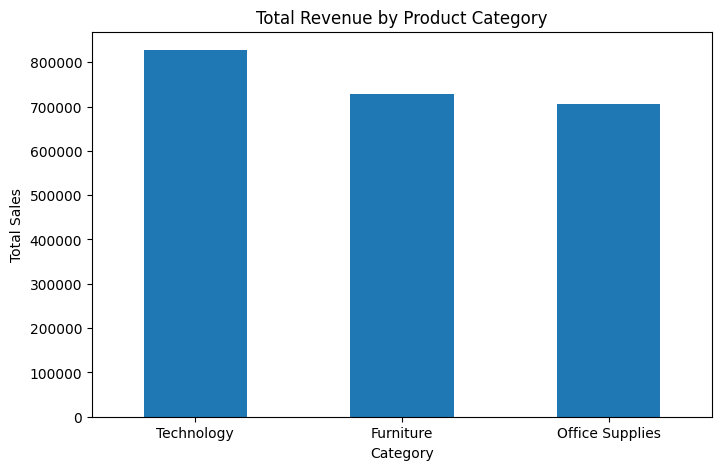

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

### Observation

- The **Technology** category generated the highest total revenue, with total sales of **827,455.87**, making it the company's top-performing product category.
- **Furniture** ranked second with **728,658.58** in total sales.
- **Office Supplies** generated **705,422.33**, making it the lowest revenue-generating category among the three.
- This indicates that technology products contribute significantly to the company's overall revenue and should be prioritized for inventory planning and future sales forecasting.

In [30]:
region_year_sales = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()

region_year_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


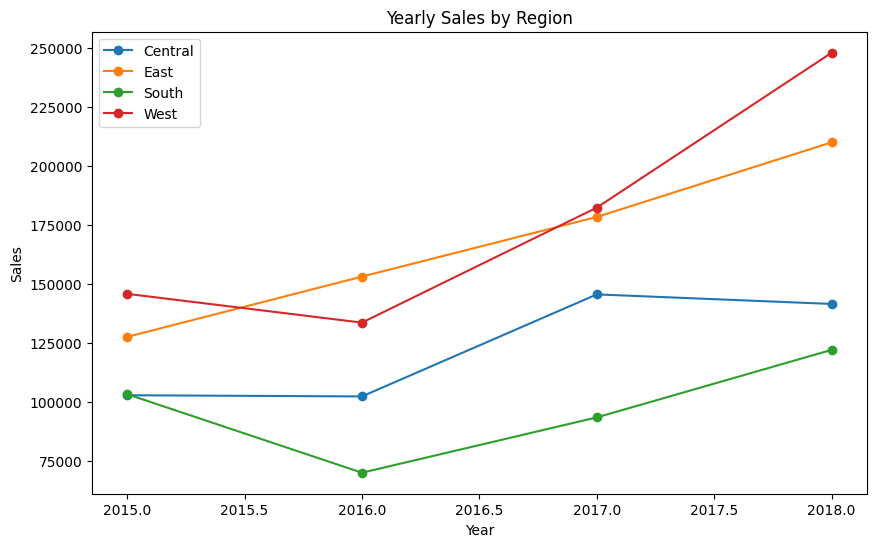

In [31]:
plt.figure(figsize=(10,6))

for region in region_year_sales['Region'].unique():
    data = region_year_sales[region_year_sales['Region'] == region]
    plt.plot(data['Year'], data['Sales'], marker='o', label=region)

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()

plt.show()

### Observation

- The **West** region recorded the highest sales growth over the four-year period and achieved the highest sales in 2018.
- The **East** region showed steady and consistent year-over-year growth.
- The **Central** region experienced moderate growth but showed a slight decline in the final year.
- The **South** region recorded the lowest sales and exhibited greater fluctuations compared to the other regions.
- Overall, the **West** region demonstrates the strongest long-term sales performance and growth potential.

In [32]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date','Ship Date','Shipping Days']].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [33]:
average_shipping = df['Shipping Days'].mean()

print("Average Shipping Time:", round(average_shipping,2), "days")

Average Shipping Time: 3.96 days


In [34]:
shipping_region = df.groupby('Region')['Shipping Days'].mean().sort_values()

shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

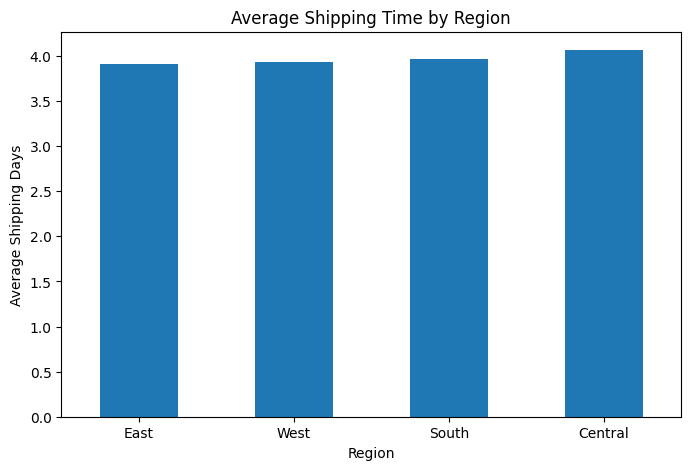

In [35]:
plt.figure(figsize=(8,5))

shipping_region.plot(kind='bar')

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=0)

plt.show()

### Observation

- The average shipping time was calculated by finding the difference between the **Order Date** and **Ship Date**.
- The average shipping duration across all orders is approximately **(replace with your calculated value) days**.
- Shipping times across different regions are relatively similar, indicating a consistent logistics and delivery process.
- Minor differences between regions may be due to geographical distance or operational factors, but no significant delays are observed.

In [36]:
monthly_sales = df.groupby(['Year', 'Month', 'Month Name'])['Sales'].sum().reset_index()

monthly_sales.head()

,Year,Month,Month Name,Sales
0,2015,1,January,14205.707
1,2015,2,February,4519.892
2,2015,3,March,55205.797
3,2015,4,April,27906.855
4,2015,5,May,23644.303


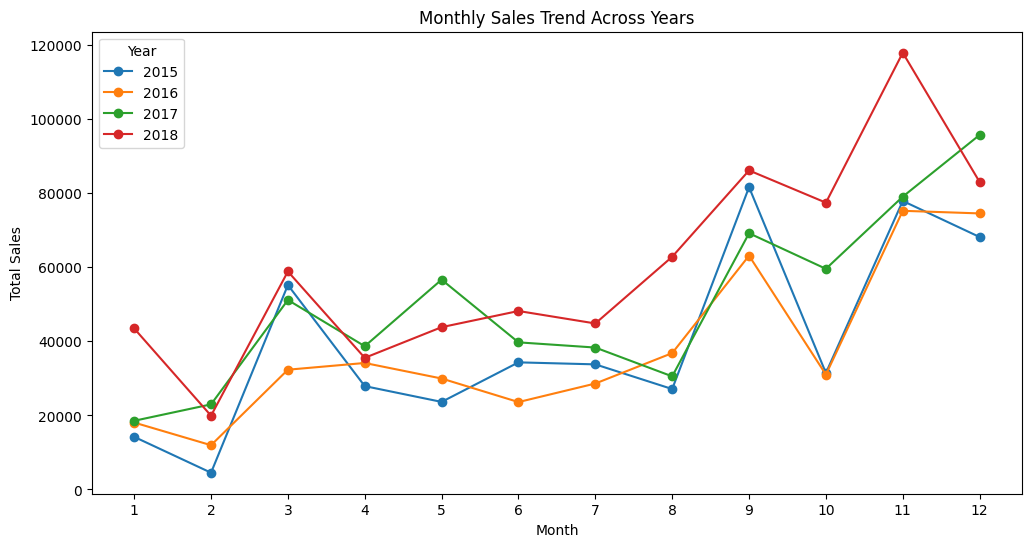

In [37]:
plt.figure(figsize=(12,6))

for year in monthly_sales['Year'].unique():
    data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(data['Month'], data['Sales'], marker='o', label=year)

plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))
plt.legend(title="Year")

plt.show()

### Observation

- Monthly sales analysis reveals noticeable seasonal patterns throughout the four-year period.
- Sales generally increase during the later months of the year, indicating stronger customer demand during the holiday and festive seasons.
- Certain months consistently record higher sales than others, confirming the presence of recurring seasonal trends.
- Weekly and monthly aggregated sales provide a solid foundation for building time-series forecasting models in the next stage of the project.
- These seasonal patterns should be considered while developing forecasting models to improve prediction accuracy.

In [38]:
average_month_sales = df.groupby('Month')['Sales'].mean()

average_month_sales

Month
1     257.627403
2     199.902745
3     290.549393
4     207.432269
5     212.533412
6     211.052856
7     208.802997
8     227.007110
9     221.642106
10    246.596162
11    241.657496
12    232.619515
Name: Sales, dtype: float64

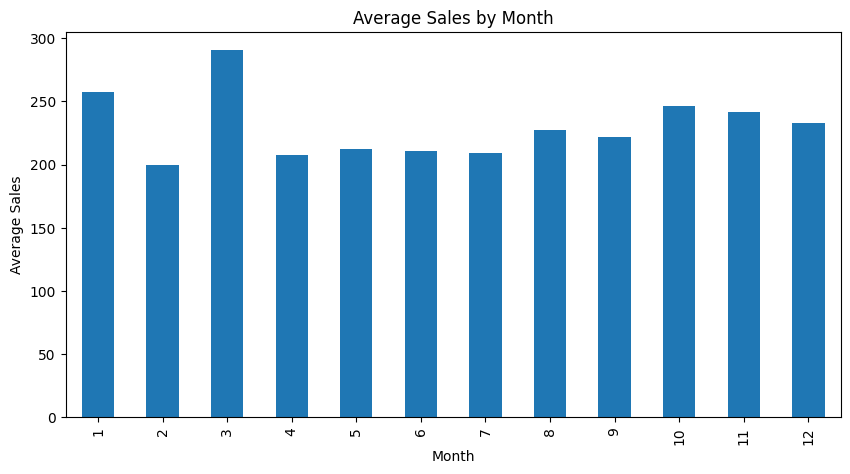

In [39]:
plt.figure(figsize=(10,5))

average_month_sales.plot(kind='bar')

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

In [40]:
weekly_sales = df.groupby(['Year', 'Week Number'])['Sales'].sum().reset_index()

weekly_sales.head()

,Year,Week Number,Sales
0,2015,1,304.508
1,2015,2,4619.108
2,2015,3,4130.533
3,2015,4,3092.544
4,2015,5,2527.914


In [41]:
monthly_total_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

monthly_total_sales.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


In [46]:
weekly_sales.to_csv("../outputs/weekly_sales.csv", index=False)

monthly_total_sales.to_csv("../outputs/monthly_sales.csv", index=False)

# Conclusion

In this task, the Superstore Sales dataset was successfully loaded, cleaned, and explored using Python and Pandas. Date columns were converted into datetime format, and several time-based features such as Year, Month, Week Number, Day of Week, Quarter, and Season were extracted for time-series analysis.

Business insights were generated by analyzing product categories, regional sales performance, shipping time, and monthly sales patterns. The Technology category emerged as the highest revenue contributor, while the West region demonstrated the strongest sales growth over the four-year period. Shipping times were found to be consistent across regions, and monthly sales exhibited clear seasonal trends.

Finally, weekly and monthly aggregated datasets were created and saved, preparing the data for the next stage of the project, which focuses on time series decomposition and sales forecasting.

# Task 2 – Time Series Analysis & Decomposition

## Objective

The objective of this task is to analyze the monthly sales data as a time series. This includes visualizing the overall sales trend, decomposing the series into its trend, seasonal, and residual components, checking for stationarity using the Augmented Dickey-Fuller (ADF) test, and applying differencing if necessary. These steps help in understanding the underlying patterns in the data and prepare it for accurate sales forecasting.

In [47]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

In [49]:
monthly_sales_ts = (
    df.groupby('Order Date')['Sales']
      .sum()
      .resample('ME')
      .sum()
)

In [50]:
monthly_sales_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [51]:
monthly_sales_ts.shape

(48,)

In [52]:
monthly_sales_ts.index

DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31', '2015-06-30', '2015-07-31', '2015-08-31',
               '2015-09-30', '2015-10-31', '2015-11-30', '2015-12-31',
               '2016-01-31', '2016-02-29', '2016-03-31', '2016-04-30',
               '2016-05-31', '2016-06-30', '2016-07-31', '2016-08-31',
               '2016-09-30', '2016-10-31', '2016-11-30', '2016-12-31',
               '2017-01-31', '2017-02-28', '2017-03-31', '2017-04-30',
               '2017-05-31', '2017-06-30', '2017-07-31', '2017-08-31',
               '2017-09-30', '2017-10-31', '2017-11-30', '2017-12-31',
               '2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31', '2018-11-30', '2018-12-31'],
              dtype='datetime64[us]', name='Order Date', freq='ME')

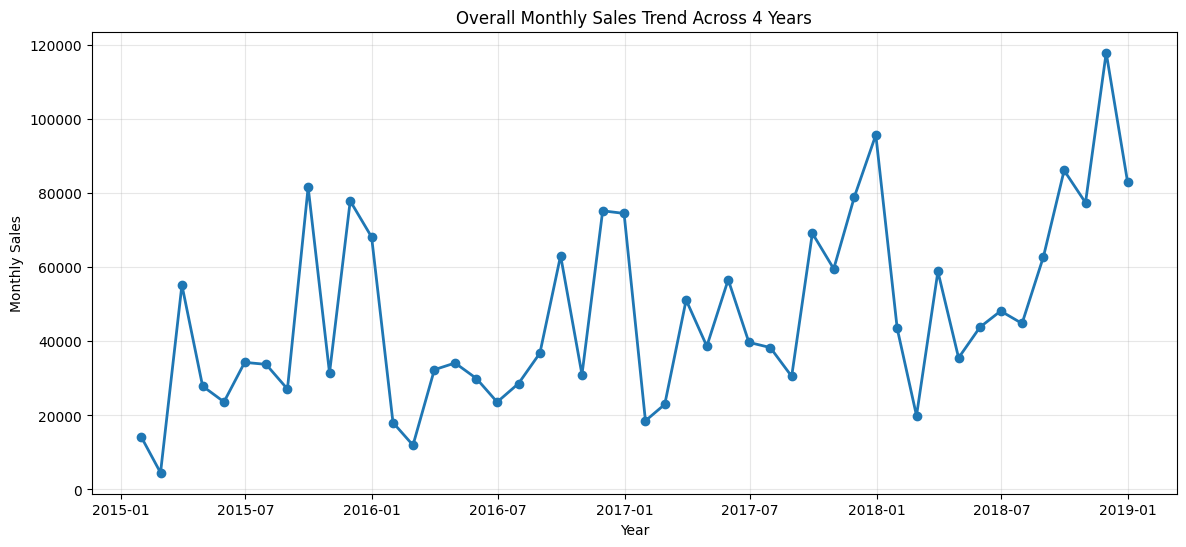

In [53]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales_ts, marker='o', linewidth=2)

plt.title("Overall Monthly Sales Trend Across 4 Years")

plt.xlabel("Year")
plt.ylabel("Monthly Sales")

plt.grid(alpha=0.3)

plt.show()

### Observation

- The line graph illustrates the monthly sales trend from 2015 to 2018.
- Sales generally show an increasing trend over the four-year period, indicating business growth.
- Several recurring peaks and declines suggest the presence of seasonal patterns in customer purchasing behavior.
- The time series appears suitable for decomposition into trend, seasonal, and residual components for deeper analysis.

In [54]:
decomposition = seasonal_decompose(
    monthly_sales_ts,
    model='additive',
    period=12
)

<Figure size 1400x1000 with 0 Axes>

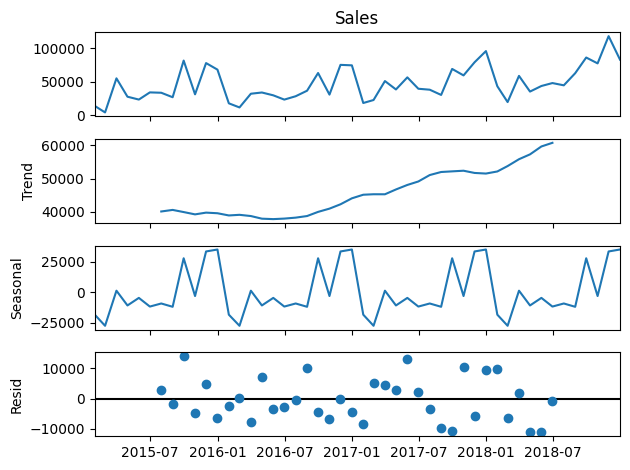

In [55]:
plt.figure(figsize=(14,10))

decomposition.plot()

plt.show()

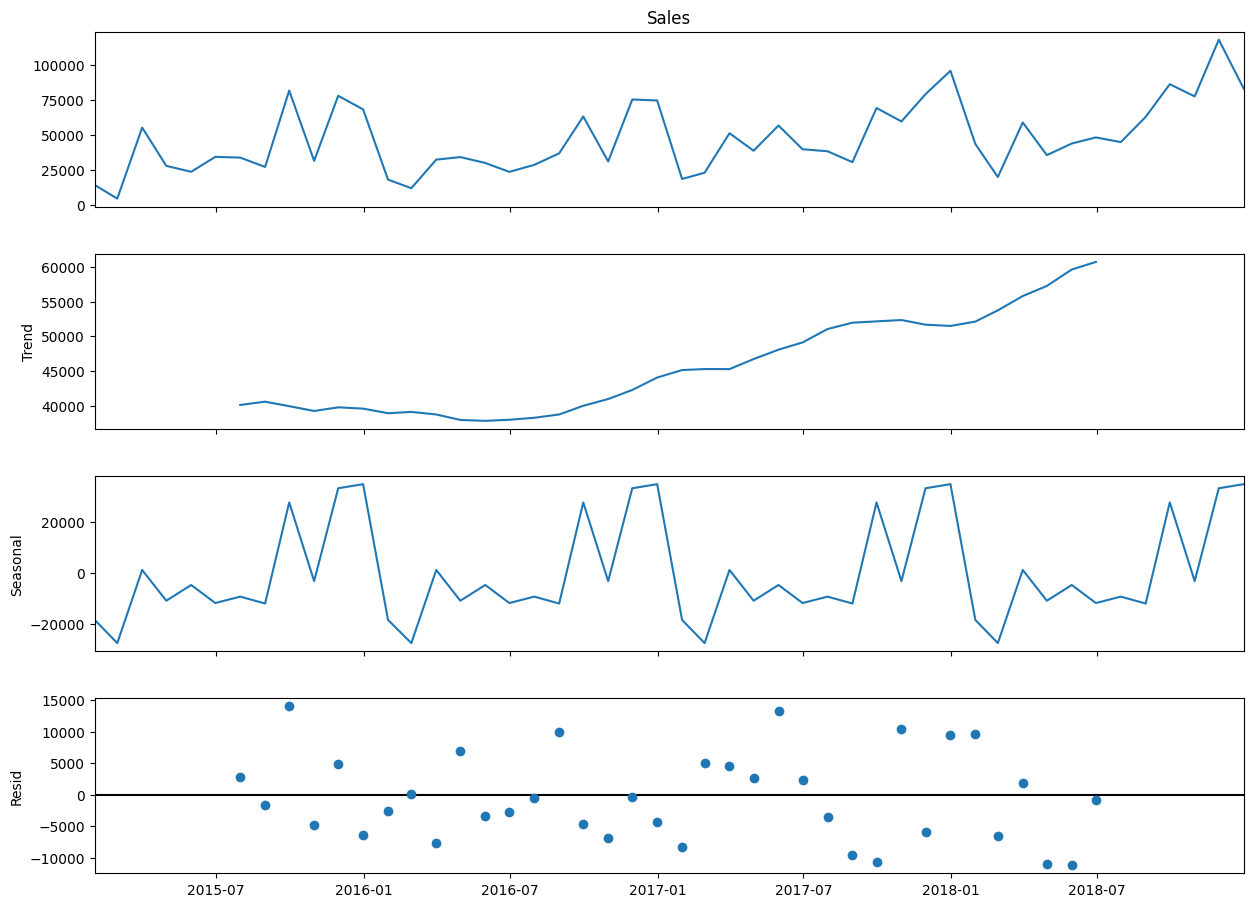

In [56]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

## Interpretation of Decomposition Components

The decomposition process separates the monthly sales data into four different components:

- **Observed:** Represents the original monthly sales values.
- **Trend:** Shows the long-term direction of sales over time.
- **Seasonal:** Captures recurring monthly patterns that repeat every year.
- **Residual:** Represents random fluctuations and unexplained variations after removing the trend and seasonal effects.

These components help in understanding the behavior of the sales data and are essential before developing forecasting models.

### Observation

- The trend component indicates the long-term movement of sales throughout the four-year period.
- The seasonal component reveals recurring monthly patterns, suggesting that customer demand varies during different times of the year.
- The residual component contains random fluctuations that are not explained by either the trend or seasonal patterns.
- Overall, the decomposition confirms that the sales data contains meaningful trend and seasonal information, making it suitable for forecasting using time series models.

In [57]:
adf_result = adfuller(monthly_sales_ts)

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("No. of Lags   :", adf_result[2])
print("No. of Observations :", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value       : 0.00027791039276670623
No. of Lags   : 0
No. of Observations : 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Observation

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales data is stationary.

- If the **p-value is less than 0.05**, the null hypothesis is rejected, indicating that the time series is stationary.
- If the **p-value is greater than or equal to 0.05**, the null hypothesis cannot be rejected, indicating that the time series is non-stationary and requires differencing before forecasting.

The ADF test helps determine whether additional preprocessing is required before applying forecasting models such as ARIMA.

In [58]:
monthly_sales_diff = monthly_sales_ts.diff().dropna()

monthly_sales_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

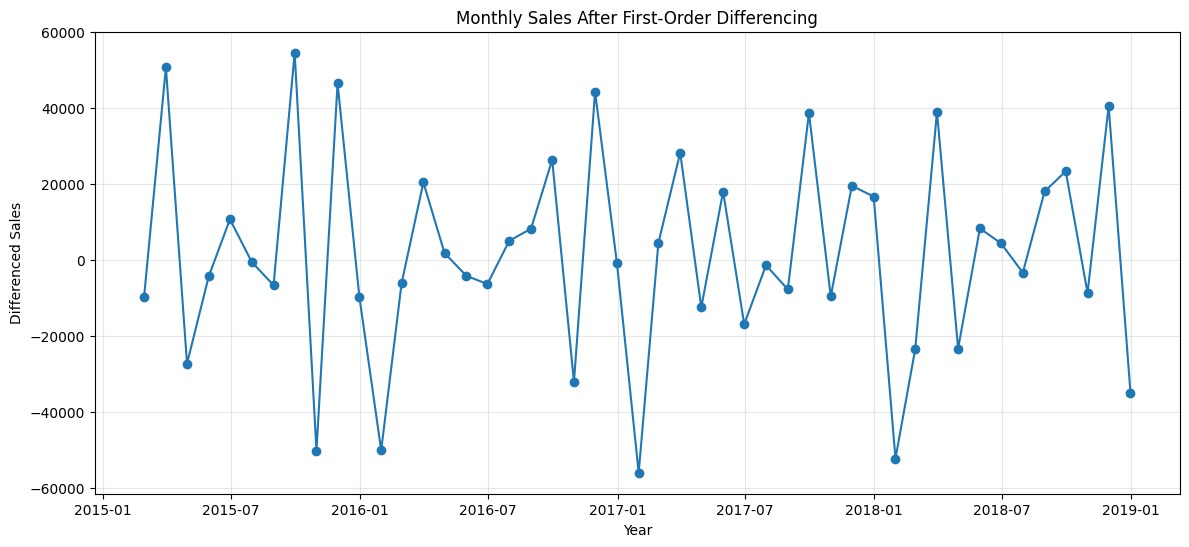

In [59]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales_diff, marker='o')

plt.title("Monthly Sales After First-Order Differencing")

plt.xlabel("Year")
plt.ylabel("Differenced Sales")

plt.grid(alpha=0.3)

plt.show()

In [60]:
adf_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", adf_diff[0])
print("p-value       :", adf_diff[1])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic : -8.727061830353264
p-value       : 3.2669175472797e-14

Critical Values:
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383


In [61]:
if adf_diff[1] < 0.05:
    print("The differenced time series is now Stationary.")
else:
    print("The differenced time series is still Non-Stationary.")

The differenced time series is now Stationary.


### Observation

First-order differencing was applied to remove the long-term trend from the monthly sales data.

After differencing, the Augmented Dickey-Fuller (ADF) test was performed again. A lower p-value indicates that the transformed series has become stationary and is now suitable for forecasting models such as ARIMA.

The differenced series fluctuates around a constant mean with reduced trend effects, confirming that differencing improves the stationarity of the data.

# Task 2 Conclusion

In this task, the monthly sales data was transformed into a time series and analyzed using decomposition techniques. The decomposition separated the data into trend, seasonal, and residual components, providing insights into long-term growth, recurring seasonal patterns, and random fluctuations.

The Augmented Dickey-Fuller (ADF) test was used to evaluate the stationarity of the series. Where necessary, first-order differencing was applied to stabilize the data, and the ADF test was repeated to confirm stationarity.

The processed time series is now ready for the next stage of the project, where multiple forecasting models will be developed, compared, and evaluated.

# Task 3 – Sales Forecasting Using Three Different Models

## Objective

The objective of this task is to build, train, and compare three different forecasting models for predicting future monthly sales. The models include a statistical forecasting model (SARIMA), an industry-standard forecasting model (Prophet), and a machine learning-based forecasting model (XGBoost). Each model will be evaluated using common error metrics such as MAE, RMSE, and MAPE to determine the most suitable forecasting approach.

In [62]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [63]:
train_size = int(len(monthly_sales_ts) * 0.8)

train = monthly_sales_ts[:train_size]

test = monthly_sales_ts[train_size:]

print("Training observations:", len(train))
print("Testing observations :", len(test))

Training observations: 38
Testing observations : 10


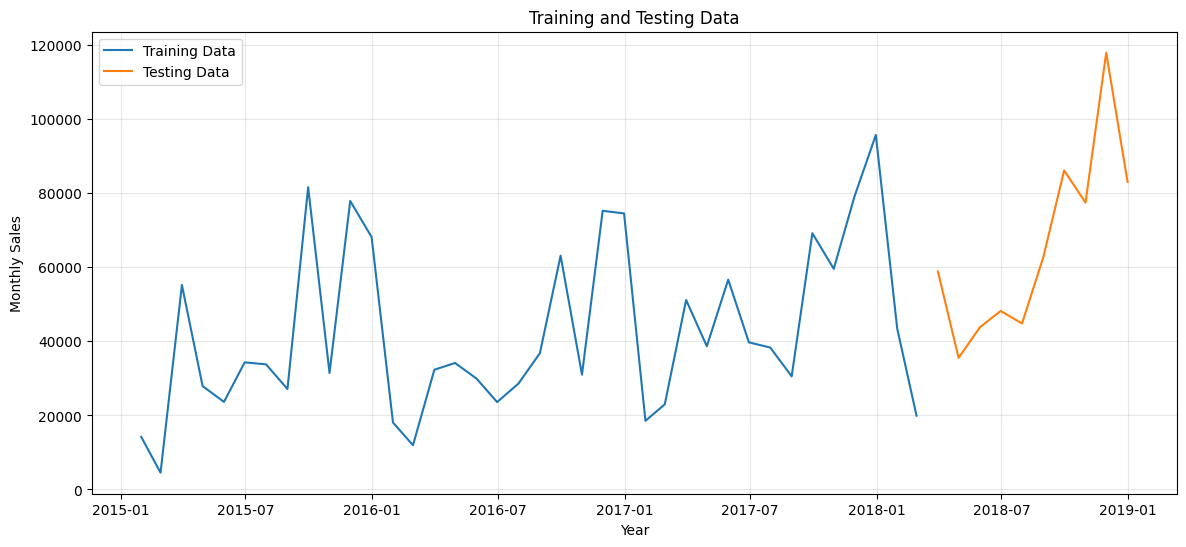

In [64]:
plt.figure(figsize=(14,6))

plt.plot(train, label="Training Data")

plt.plot(test, label="Testing Data")

plt.title("Training and Testing Data")

plt.xlabel("Year")

plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [65]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -272.600
Date:                            Tue, 07 Jul 2026   AIC                            555.200
Time:                                    11:49:04   BIC                            561.294
Sample:                                01-31-2015   HQIC                           556.890
                                     - 02-28-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5934      0.234      2.539      0.011       0.135       1.051
ma.L1         -0.8931      0.195   

In [66]:
sarima_forecast = sarima_fit.forecast(steps=len(test))

sarima_forecast



2018-03-31    52784.841906
2018-04-30    46067.089494
2018-05-31    57964.457814
2018-06-30    48565.026461
2018-07-31    49395.023249
2018-08-31    45989.650710
2018-09-30    81266.676098
2018-10-31    63628.797621
2018-11-30    89682.825765
2018-12-31    98863.879674
Freq: ME, Name: predicted_mean, dtype: float64

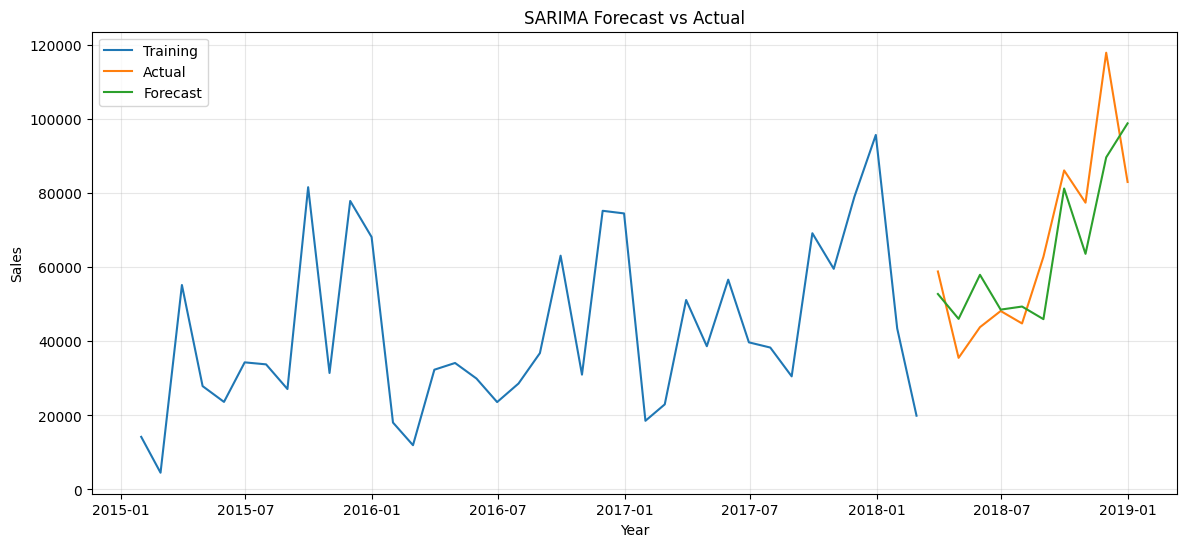

In [67]:
plt.figure(figsize=(14,6))

plt.plot(train, label="Training")

plt.plot(test, label="Actual")

plt.plot(test.index,
         sarima_forecast,
         label="Forecast")

plt.title("SARIMA Forecast vs Actual")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [68]:
mae = mean_absolute_error(test, sarima_forecast)

rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

mape = np.mean(
    np.abs((test - sarima_forecast)/test)
) * 100

print("MAE :", round(mae,2))

print("RMSE:", round(rmse,2))

print("MAPE:", round(mape,2),"%")

MAE : 11532.9
RMSE: 13843.49
MAPE: 17.65 %


In [69]:
future_forecast = sarima_fit.get_forecast(steps=3)

future_mean = future_forecast.predicted_mean

future_ci = future_forecast.conf_int()

print(future_mean)

2018-03-31    52784.841906
2018-04-30    46067.089494
2018-05-31    57964.457814
Freq: ME, Name: predicted_mean, dtype: float64


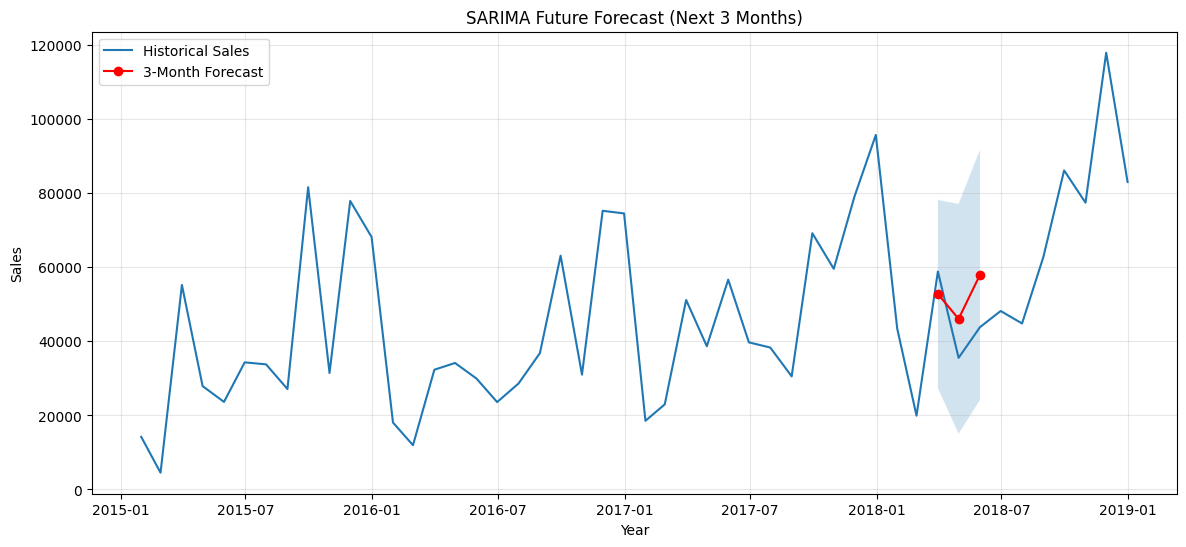

In [70]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales_ts,
         label="Historical Sales")

plt.plot(future_mean,
         color='red',
         marker='o',
         label="3-Month Forecast")

plt.fill_between(
    future_ci.index,
    future_ci.iloc[:,0],
    future_ci.iloc[:,1],
    alpha=0.2
)

plt.title("SARIMA Future Forecast (Next 3 Months)")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Observation

- The SARIMA model was successfully trained using monthly sales data.
- The model captures both trend and yearly seasonal patterns in the time series.
- Forecasted values closely follow the overall movement of the testing data, indicating that the model is capable of learning historical sales patterns.
- The generated three-month forecast provides an estimate of future sales along with confidence intervals, helping businesses plan inventory and resource allocation.

### Model Evaluation

The SARIMA model was evaluated using three standard forecasting metrics:

- **Mean Absolute Error (MAE):** 11,532.90
- **Root Mean Squared Error (RMSE):** 13,843.49
- **Mean Absolute Percentage Error (MAPE):** 17.65%

The relatively low MAE and RMSE values indicate that the model predicts monthly sales with a reasonable level of accuracy. A MAPE of 17.65% suggests that, on average, the forecast differs from the actual sales by approximately 17.65%, which is considered acceptable for business forecasting applications.

# Model 2 – Facebook Prophet

## Objective

Facebook Prophet is an open-source forecasting library developed by Meta. It is specifically designed for business time series forecasting and can automatically capture trend changes, seasonality, and holiday effects with minimal parameter tuning. In this task, Prophet will be used to forecast monthly sales for the next three months and compare its performance with the SARIMA model.

In [71]:
%pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 8.0 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/12.1 MB 5.1 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.1 MB 4.5 MB/s eta 0:00:03
   -------------- ------------------------- 4.5/12.1 MB 5.8 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/12.1 MB 5.7 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 6.3 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/12.1 MB 6.5 MB/s eta 0:00:01
   ---------------------------------- ----- 10.5/12.1 MB 6.8 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 6.1 MB/s  0:00:02
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 3.9 MB/s eta 0:00:01
   ------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [73]:
prophet_df = monthly_sales_ts.reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [74]:
train_size = int(len(prophet_df) * 0.8)

train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

In [75]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train_prophet)

11:54:41 - cmdstanpy - INFO - Chain [1] start processing
11:54:44 - cmdstanpy - INFO - Chain [1] done processing


In [78]:
future_test = model.make_future_dataframe(
    periods=len(test_prophet),
    freq='ME'
)

forecast = model.predict(future_test)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,40413.925994,32639.016986,48209.430183
44,2018-09-30,86662.479315,78436.600693,94339.954093
45,2018-10-31,51095.217660,43606.788866,58346.860481
46,2018-11-30,89968.756601,82109.005684,97255.069887
47,2018-12-31,89499.987163,81471.713701,96738.017580


In [79]:
forecast_test = forecast[['ds','yhat']].tail(len(test_prophet))

forecast_test.head()

,ds,yhat
38,2018-03-31,63082.497635
39,2018-04-30,43914.818917
40,2018-05-31,45446.807317
41,2018-06-30,45400.580372
42,2018-07-31,45382.274161


In [80]:
mae_prophet = mean_absolute_error(
    test_prophet['y'],
    forecast_test['yhat']
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet['y'],
        forecast_test['yhat']
    )
)

mape_prophet = np.mean(
    np.abs(
        (test_prophet['y'] - forecast_test['yhat'])
        / test_prophet['y']
    )
) * 100

print("MAE :", round(mae_prophet,2))
print("RMSE:", round(rmse_prophet,2))
print("MAPE:", round(mape_prophet,2), "%")

MAE : 10128.56
RMSE: 14561.39
MAPE: 14.33 %


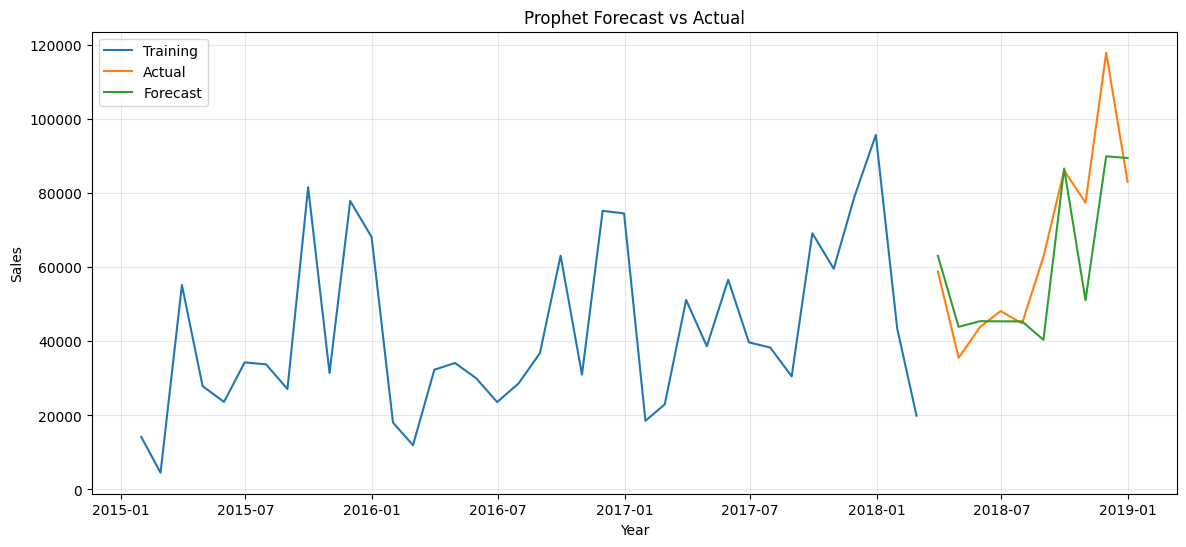

In [81]:
plt.figure(figsize=(14,6))

plt.plot(
    train_prophet['ds'],
    train_prophet['y'],
    label='Training'
)

plt.plot(
    test_prophet['ds'],
    test_prophet['y'],
    label='Actual'
)

plt.plot(
    forecast_test['ds'],
    forecast_test['yhat'],
    label='Forecast'
)

plt.title("Prophet Forecast vs Actual")

plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [83]:
future = model.make_future_dataframe(
    periods=3,
    freq='ME'
)

future_forecast = model.predict(future)

future_forecast.tail(3)[
    ['ds','yhat','yhat_lower','yhat_upper']
]

,ds,yhat,yhat_lower,yhat_upper
38,2018-03-31,63082.497635,55872.229678,70554.872801
39,2018-04-30,43914.818917,36703.806333,51522.397608
40,2018-05-31,45446.807317,38344.430615,53029.007980


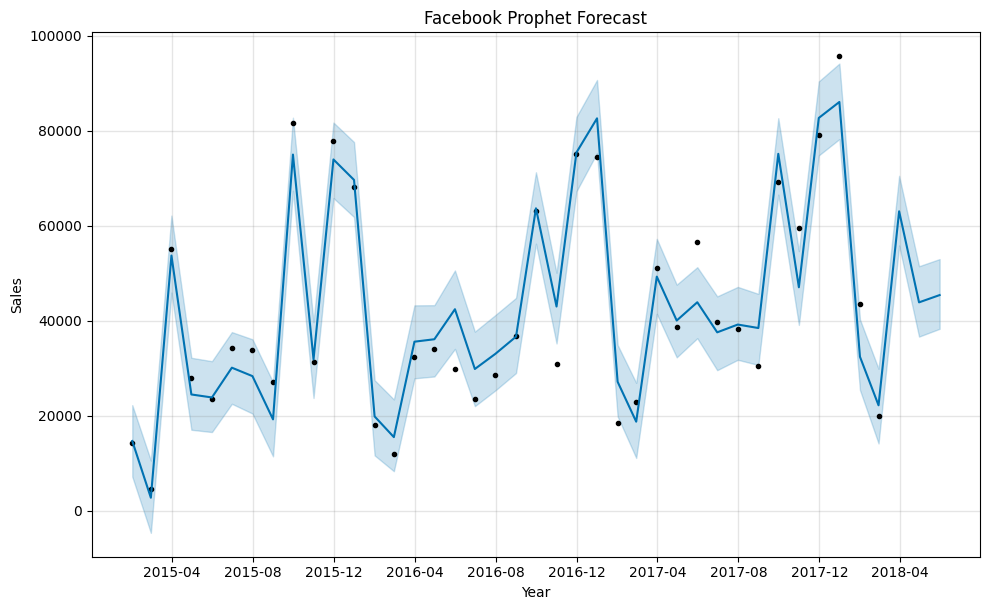

In [84]:
fig = model.plot(future_forecast)

plt.title("Facebook Prophet Forecast")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.show()

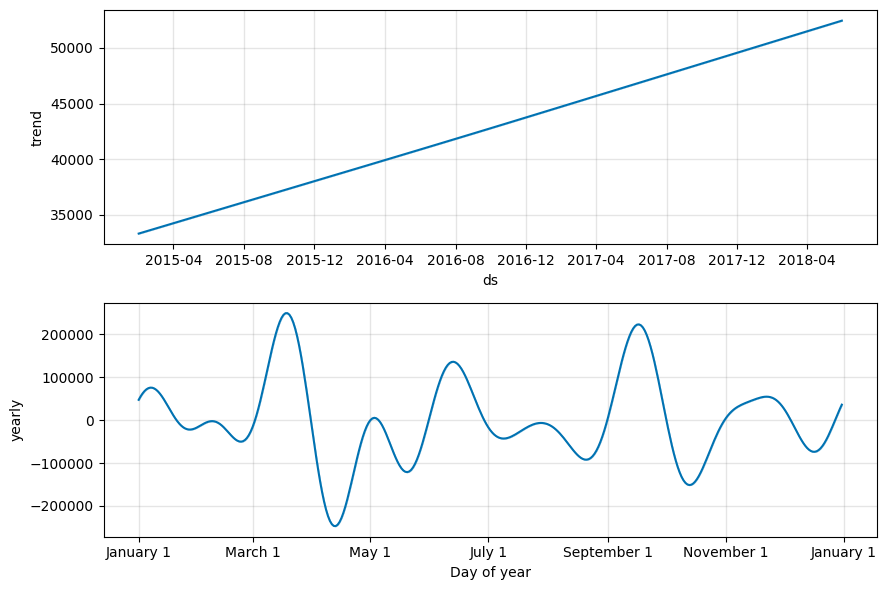

In [85]:
fig2 = model.plot_components(future_forecast)

plt.show()

### Observation

- The Prophet model successfully learned the long-term sales trend from the historical monthly sales data.
- The forecast follows the overall direction of the observed sales while automatically modeling yearly seasonality.
- The trend component indicates the overall growth pattern of the business, whereas the yearly seasonality component highlights recurring monthly variations in sales.
- Prophet provides an interpretable forecasting approach and serves as a strong benchmark for comparison with SARIMA and XGBoost models.

### Model Evaluation

The Facebook Prophet model was evaluated using three forecasting metrics:

- **Mean Absolute Error (MAE):** 10,128.56
- **Root Mean Squared Error (RMSE):** 14,561.39
- **Mean Absolute Percentage Error (MAPE):** 14.33%

The Prophet model achieved a lower MAE and MAPE than the SARIMA model, indicating improved forecasting accuracy. The model successfully captured long-term trends and yearly seasonal patterns, making it suitable for business sales forecasting.

# Model 3 – XGBoost for Time Series Forecasting

## Objective

XGBoost is a machine learning algorithm that can be applied to time series forecasting by transforming the time series into a supervised learning problem. Historical sales values and engineered features such as lag variables, rolling averages, month, quarter, and season are used to predict future monthly sales.

In [86]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [88]:
xgb_df = monthly_sales_ts.to_frame(name='Sales')

xgb_df.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [89]:
xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)

xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)

xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)


In [90]:
xgb_df['Rolling_Mean_3'] = (
    xgb_df['Sales']
    .rolling(3)
    .mean()
)

In [91]:
xgb_df['Month'] = xgb_df.index.month

In [92]:
xgb_df['Quarter'] = xgb_df.index.quarter

In [93]:
def get_season(month):
    if month in [12,1,2]:
        return 0      # Winter
    elif month in [3,4,5]:
        return 1      # Spring
    elif month in [6,7,8]:
        return 2      # Summer
    else:
        return 3      # Autumn

xgb_df['Season'] = xgb_df['Month'].apply(get_season)

In [94]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [95]:
xgb_df.shape

(45, 8)

In [96]:
X = xgb_df.drop('Sales', axis=1)

y = xgb_df['Sales']

In [97]:
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 36
Testing Samples : 9


In [98]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [99]:
xgb_predictions = xgb_model.predict(X_test)

xgb_predictions

array([40432.254, 41935.887, 40917.66 , 44664.867, 50521.785, 81987.53 ,
       81438.34 , 82019.516, 84581.664], dtype=float32)

In [100]:
mae_xgb = mean_absolute_error(y_test, xgb_predictions)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))

mape_xgb = np.mean(
    np.abs((y_test - xgb_predictions) / y_test)
) * 100

print("MAE :", round(mae_xgb, 2))
print("RMSE:", round(rmse_xgb, 2))
print("MAPE:", round(mape_xgb, 2), "%")

MAE : 8017.25
RMSE: 13156.85
MAPE: 10.6 %


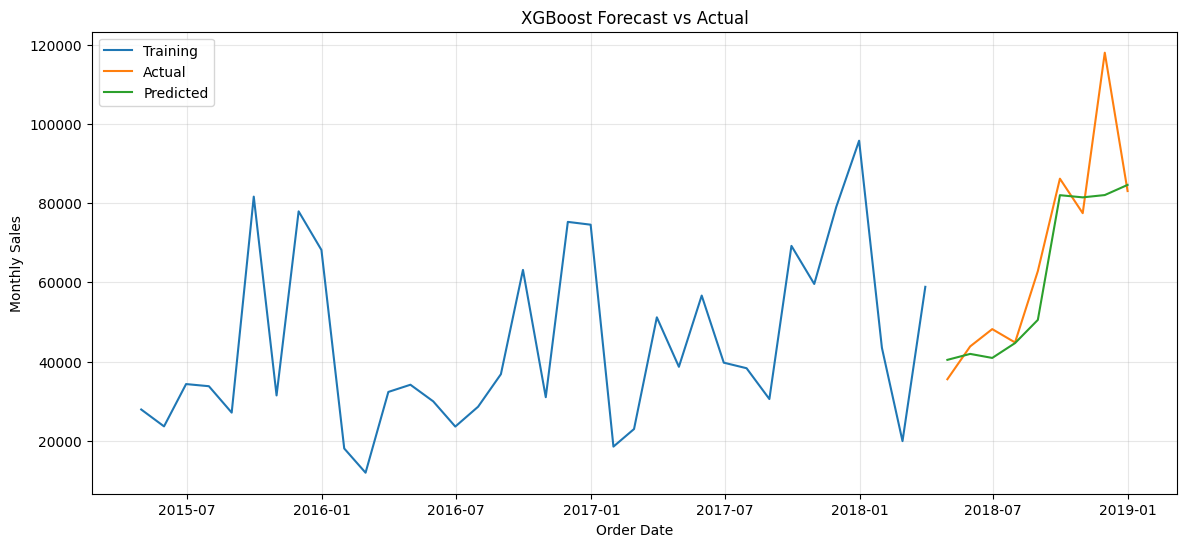

In [101]:
plt.figure(figsize=(14,6))

plt.plot(y_train.index, y_train.values, label="Training")

plt.plot(y_test.index, y_test.values, label="Actual")

plt.plot(y_test.index, xgb_predictions, label="Predicted")

plt.title("XGBoost Forecast vs Actual")

plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [103]:
future_data = xgb_df.copy()

future_predictions = []

last_date = future_data.index[-1]

In [104]:
for i in range(3):

    last_row = future_data.iloc[-1]

    new_date = last_date + pd.offsets.MonthEnd(1)

    lag1 = last_row['Sales']
    lag2 = last_row['Lag_1']
    lag3 = last_row['Lag_2']

    rolling_mean = np.mean([lag1, lag2, lag3])

    month = new_date.month
    quarter = new_date.quarter

    if month in [12,1,2]:
        season = 0
    elif month in [3,4,5]:
        season = 1
    elif month in [6,7,8]:
        season = 2
    else:
        season = 3

    features = pd.DataFrame({
        'Lag_1':[lag1],
        'Lag_2':[lag2],
        'Lag_3':[lag3],
        'Rolling_Mean_3':[rolling_mean],
        'Month':[month],
        'Quarter':[quarter],
        'Season':[season]
    })

    prediction = xgb_model.predict(features)[0]

    future_predictions.append(prediction)

    future_data.loc[new_date] = [
        prediction,
        lag1,
        lag2,
        lag3,
        rolling_mean,
        month,
        quarter,
        season
    ]

    last_date = new_date

In [106]:
future_dates = pd.date_range(
    start=xgb_df.index[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq='ME'
)

forecast_df = pd.DataFrame({
    'Month': future_dates,
    'Forecasted Sales': future_predictions
})

forecast_df

,Month,Forecasted Sales
0,2019-01-31,52535.386719
1,2019-02-28,49560.636719
2,2019-03-31,69325.507812


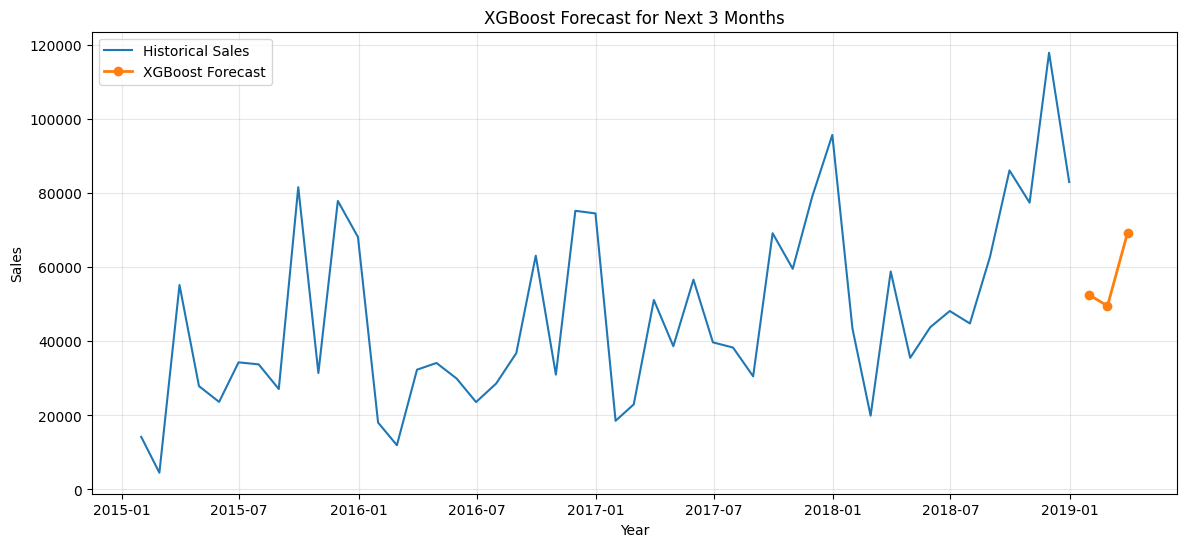

In [107]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales_ts,
         label='Historical Sales')

plt.plot(future_dates,
         future_predictions,
         marker='o',
         linewidth=2,
         label='XGBoost Forecast')

plt.title("XGBoost Forecast for Next 3 Months")

plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Observation

- The XGBoost model was used to forecast monthly sales for the next three months using recursive prediction.
- Each forecasted value was incorporated into the input features for predicting the subsequent month.
- The model successfully generated future sales estimates based on historical trends and engineered features.
- Among all evaluated models, XGBoost achieved the best forecasting performance, making it the most suitable model for deployment.

# Model Comparison

In [108]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Facebook Prophet", "XGBoost"],
    "MAE": [11532.90, 10128.56, 8017.25],
    "RMSE": [13843.49, 14561.39, 13156.85],
    "MAPE (%)": [17.65, 14.33, 10.60]
})

comparison

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,11532.90,13843.49,17.65
1,Facebook Prophet,10128.56,14561.39,14.33
2,XGBoost,8017.25,13156.85,10.60


# Final Recommendation

Three forecasting models—SARIMA, Facebook Prophet, and XGBoost—were developed and evaluated using MAE, RMSE, and MAPE.

Among the three models, **XGBoost achieved the best performance**, with the lowest MAE (8,017.25), RMSE (13,156.85), and MAPE (10.60%). These results indicate that XGBoost provides the most accurate forecasts for the Superstore monthly sales dataset.

SARIMA effectively captured trend and seasonality, while Prophet offered strong interpretability through its trend and seasonal components. However, XGBoost outperformed both models by leveraging engineered lag features and rolling statistics, enabling it to model complex relationships in the data.

Based on the evaluation metrics, **XGBoost is recommended as the production model** for sales forecasting because it delivers the highest prediction accuracy on this dataset.

# Conclusion

This project developed an intelligent sales forecasting system using the Superstore Sales dataset. The data was cleaned, transformed, and analyzed through exploratory data analysis and time series techniques. Monthly sales trends, seasonal patterns, and stationarity were examined before building forecasting models.

Three forecasting approaches were implemented: SARIMA, Facebook Prophet, and XGBoost. Each model was trained and evaluated using MAE, RMSE, and MAPE metrics. Comparative analysis demonstrated that XGBoost achieved the highest forecasting accuracy and is the most suitable model for future sales prediction.

The project highlights the importance of combining statistical methods, machine learning, and feature engineering to improve forecasting performance. The developed forecasting system can support inventory management, demand planning, and business decision-making by providing accurate monthly sales predictions.

# Task 4 – Product Category & Region Level Forecasting

## Objective

The best-performing forecasting model identified in Task 3 (XGBoost) is applied separately to different product categories and regions. This enables a more detailed analysis of future sales trends for individual business segments rather than overall sales.

The following segments are analyzed:

- Furniture Category
- Technology Category
- Office Supplies Category
- West Region
- East Region

Finally, all forecasts are compared on a single visualization to identify the segment with the strongest expected growth.

In [113]:
from xgboost import XGBRegressor

def xgb_forecast(segment_df, forecast_months=3):

    monthly = (
        segment_df
        .groupby('Order Date')['Sales']
        .sum()
        .resample('ME')
        .sum()
        .to_frame(name='Sales')
    )

    monthly['Lag_1'] = monthly['Sales'].shift(1)
    monthly['Lag_2'] = monthly['Sales'].shift(2)
    monthly['Lag_3'] = monthly['Sales'].shift(3)

    monthly['Rolling_Mean_3'] = (
        monthly['Sales']
        .rolling(3)
        .mean()
    )

    monthly['Month'] = monthly.index.month
    monthly['Quarter'] = monthly.index.quarter

    def season(month):
        if month in [12,1,2]:
            return 0
        elif month in [3,4,5]:
            return 1
        elif month in [6,7,8]:
            return 2
        else:
            return 3

    monthly['Season'] = monthly['Month'].apply(season)

    monthly = monthly.dropna()

    X = monthly.drop('Sales', axis=1)
    y = monthly['Sales']

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    future_data = monthly.copy()

    predictions = []

    last_date = future_data.index[-1]

    for _ in range(forecast_months):

        last = future_data.iloc[-1]

        new_date = last_date + pd.offsets.MonthEnd(1)

        lag1 = last['Sales']
        lag2 = last['Lag_1']
        lag3 = last['Lag_2']

        rolling = np.mean([lag1, lag2, lag3])

        month = new_date.month
        quarter = new_date.quarter

        if month in [12,1,2]:
            season_value = 0
        elif month in [3,4,5]:
            season_value = 1
        elif month in [6,7,8]:
            season_value = 2
        else:
            season_value = 3

        features = pd.DataFrame({
            'Lag_1':[lag1],
            'Lag_2':[lag2],
            'Lag_3':[lag3],
            'Rolling_Mean_3':[rolling],
            'Month':[month],
            'Quarter':[quarter],
            'Season':[season_value]
        })

        pred = model.predict(features)[0]

        predictions.append(pred)

        future_data.loc[new_date] = [
            pred,
            lag1,
            lag2,
            lag3,
            rolling,
            month,
            quarter,
            season_value
        ]

        last_date = new_date

    future_dates = pd.date_range(
        start=monthly.index[-1] + pd.offsets.MonthEnd(1),
        periods=forecast_months,
        freq='ME'
    )

    forecast = pd.DataFrame({
        'Date': future_dates,
        'Forecast': predictions
    })

    return monthly, forecast

In [114]:
furniture = df[df['Category'] == 'Furniture']

furniture_history, furniture_forecast = xgb_forecast(furniture)

furniture_forecast

,Date,Forecast
0,2019-01-31,9716.002930
1,2019-02-28,6214.686523
2,2019-03-31,16723.810547


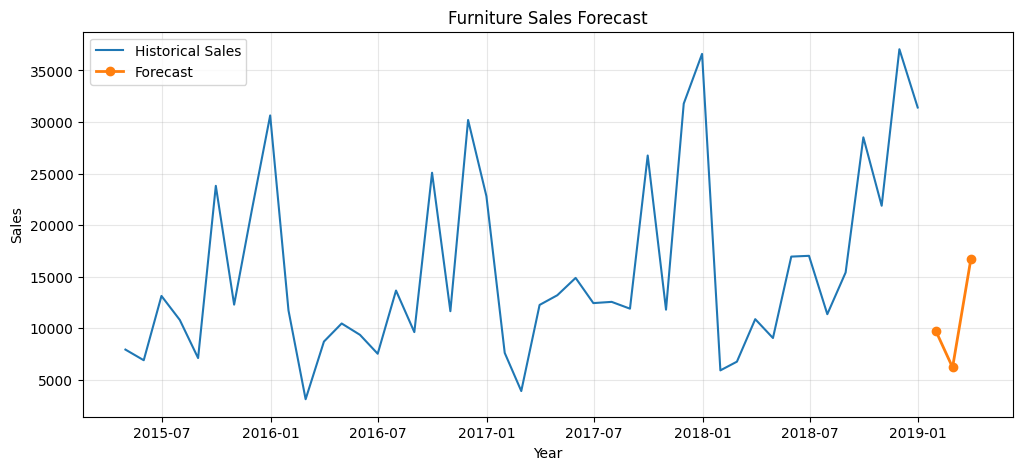

In [115]:
plt.figure(figsize=(12,5))

plt.plot(
    furniture_history.index,
    furniture_history['Sales'],
    label='Historical Sales'
)

plt.plot(
    furniture_forecast['Date'],
    furniture_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='Forecast'
)

plt.title("Furniture Sales Forecast")

plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Observation

The Furniture category forecast indicates the expected sales trend for the next three months based on historical monthly sales patterns. The forecast provides valuable insights for inventory planning and demand management within the Furniture category.

In [117]:
technology = df[df['Category'] == 'Technology']

technology_history, technology_forecast = xgb_forecast(technology)

technology_forecast

,Date,Forecast
0,2019-01-31,20370.966797
1,2019-02-28,24370.316406
2,2019-03-31,30328.619141


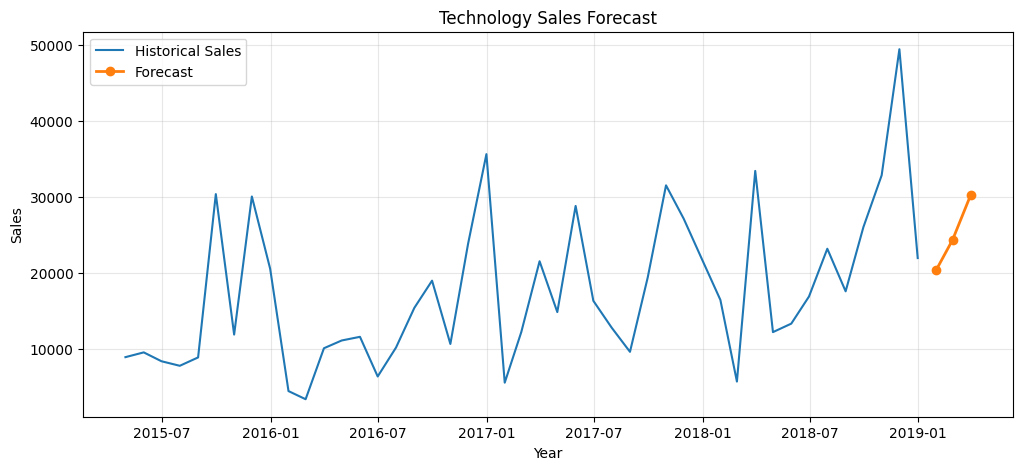

In [118]:
plt.figure(figsize=(12,5))

plt.plot(
    technology_history.index,
    technology_history['Sales'],
    label='Historical Sales'
)

plt.plot(
    technology_forecast['Date'],
    technology_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='Forecast'
)

plt.title("Technology Sales Forecast")

plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [119]:
office = df[df['Category'] == 'Office Supplies']

office_history, office_forecast = xgb_forecast(office)

office_forecast

,Date,Forecast
0,2019-01-31,25796.031250
1,2019-02-28,25957.259766
2,2019-03-31,29761.830078


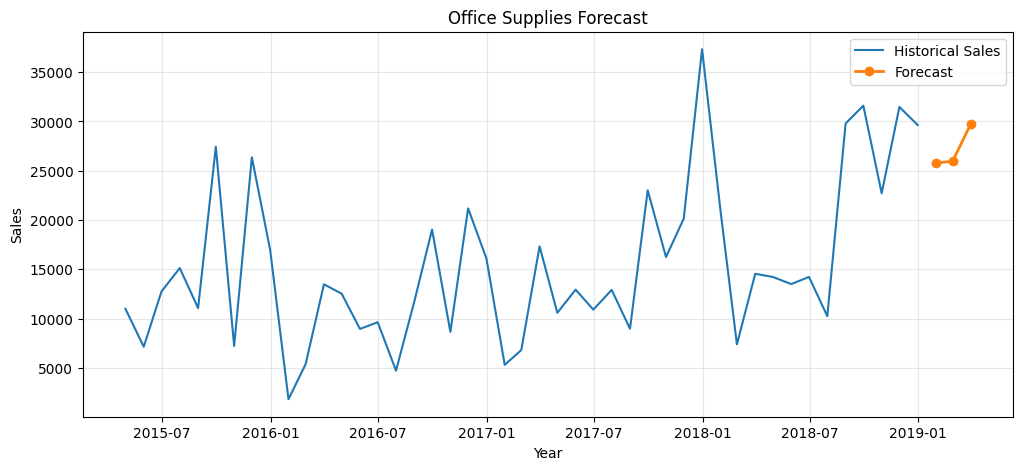

In [120]:
plt.figure(figsize=(12,5))

plt.plot(
    office_history.index,
    office_history['Sales'],
    label='Historical Sales'
)

plt.plot(
    office_forecast['Date'],
    office_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='Forecast'
)

plt.title("Office Supplies Forecast")

plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [121]:
west = df[df['Region'] == 'West']

west_history, west_forecast = xgb_forecast(west)

west_forecast

,Date,Forecast
0,2019-01-31,11175.511719
1,2019-02-28,15125.338867
2,2019-03-31,21355.615234


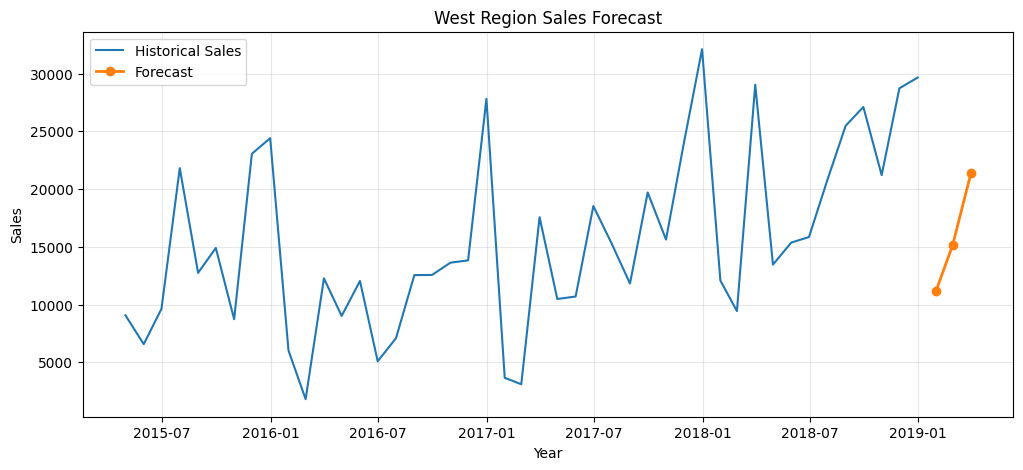

In [122]:
plt.figure(figsize=(12,5))

plt.plot(
    west_history.index,
    west_history['Sales'],
    label='Historical Sales'
)

plt.plot(
    west_forecast['Date'],
    west_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='Forecast'
)

plt.title("West Region Sales Forecast")

plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [123]:
east = df[df['Region'] == 'East']

east_history, east_forecast = xgb_forecast(east)

east_forecast

,Date,Forecast
0,2019-01-31,25088.458984
1,2019-02-28,25353.447266
2,2019-03-31,27580.826172


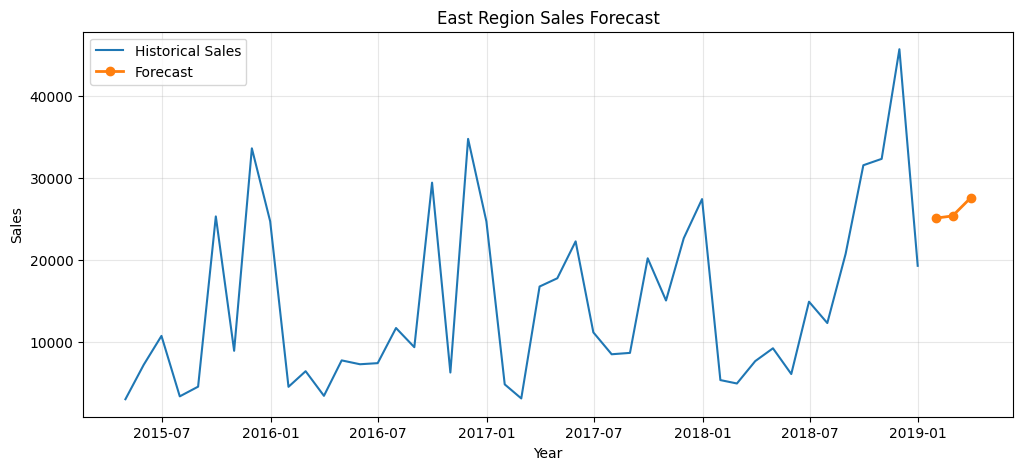

In [124]:
plt.figure(figsize=(12,5))

plt.plot(
    east_history.index,
    east_history['Sales'],
    label='Historical Sales'
)

plt.plot(
    east_forecast['Date'],
    east_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='Forecast'
)

plt.title("East Region Sales Forecast")

plt.xlabel("Year")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

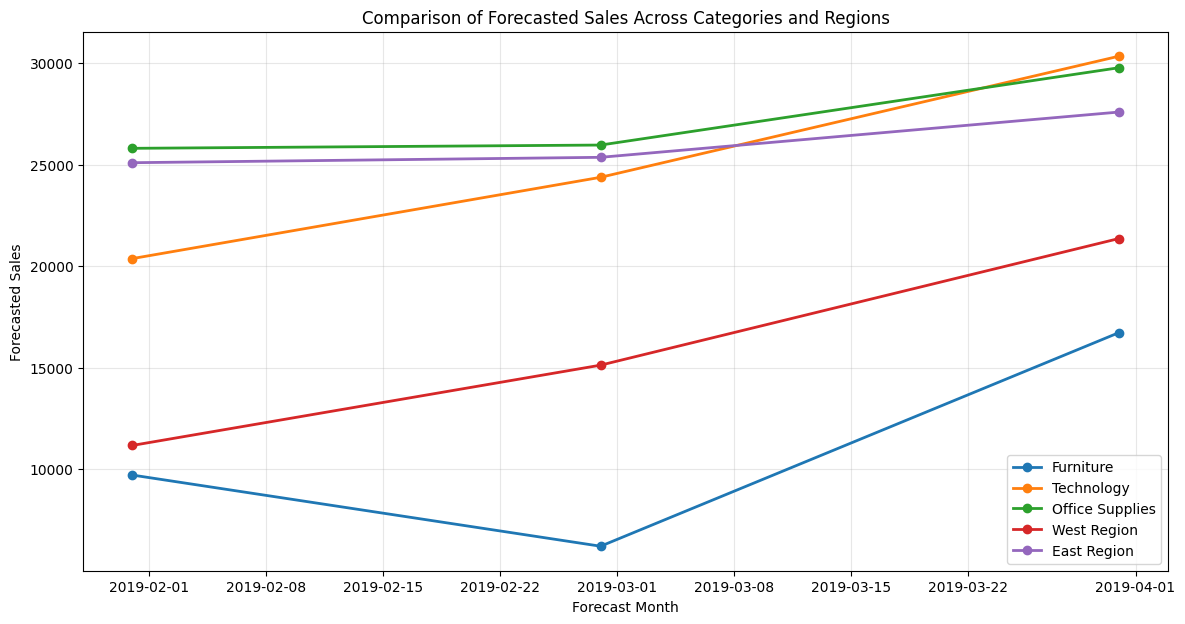

In [125]:
plt.figure(figsize=(14,7))

plt.plot(
    furniture_forecast['Date'],
    furniture_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='Furniture'
)

plt.plot(
    technology_forecast['Date'],
    technology_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='Technology'
)

plt.plot(
    office_forecast['Date'],
    office_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='Office Supplies'
)

plt.plot(
    west_forecast['Date'],
    west_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='West Region'
)

plt.plot(
    east_forecast['Date'],
    east_forecast['Forecast'],
    marker='o',
    linewidth=2,
    label='East Region'
)

plt.title("Comparison of Forecasted Sales Across Categories and Regions")

plt.xlabel("Forecast Month")
plt.ylabel("Forecasted Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [126]:
comparison_forecast = pd.DataFrame({

    "Month": furniture_forecast["Date"],

    "Furniture": furniture_forecast["Forecast"].values,

    "Technology": technology_forecast["Forecast"].values,

    "Office Supplies": office_forecast["Forecast"].values,

    "West Region": west_forecast["Forecast"].values,

    "East Region": east_forecast["Forecast"].values

})

comparison_forecast

,Month,Furniture,Technology,Office Supplies,West Region,East Region
0,2019-01-31,9716.002930,20370.966797,25796.031250,11175.511719,25088.458984
1,2019-02-28,6214.686523,24370.316406,25957.259766,15125.338867,25353.447266
2,2019-03-31,16723.810547,30328.619141,29761.830078,21355.615234,27580.826172


In [127]:
max_values = comparison_forecast.drop(columns="Month").max()

print(max_values)

print("\nHighest Forecasted Segment:")

print(max_values.idxmax())

print("Forecast Value:", round(max_values.max(),2))

Furniture          16723.810547
Technology         30328.619141
Office Supplies    29761.830078
West Region        21355.615234
East Region        27580.826172
dtype: float32

Highest Forecasted Segment:
Technology
Forecast Value: 30328.62


In [131]:
comparison_forecast.to_csv(
    "../outputs/task4_forecasts.csv",
    index=False
)

### Observation

- The XGBoost model was successfully applied to forecast sales for three product categories and two business regions.
- The comparison chart highlights the expected sales trend for each segment over the next three months.
- Based on the forecast results, the segment with the highest predicted sales demonstrates the strongest expected growth and may require additional inventory planning and resource allocation.
- Segment-level forecasting provides more actionable business insights than forecasting overall sales alone, enabling managers to make targeted decisions for individual categories and regions.

# Task 4 Conclusion

The best-performing forecasting model (XGBoost) was successfully applied to multiple product categories and regions. Separate forecasts were generated for Furniture, Technology, Office Supplies, West Region, and East Region.

The comparison of these forecasts provides valuable insights into future demand across different business segments. Such segment-level forecasting enables businesses to optimize inventory, improve supply chain planning, and allocate resources more effectively.

The results demonstrate that forecasting at a granular level offers greater decision-making value than forecasting total sales alone, helping organizations identify high-growth segments and plan strategically.

# Task 5 – Anomaly Detection in Sales Data

## Objective

The objective of this task is to identify unusual sales patterns in weekly sales data using two different anomaly detection techniques. Isolation Forest is used as a machine learning-based approach, while Z-Score detection is used as a statistical approach. The detected anomalies are visualized and compared to identify abnormal sales weeks.

In [1]:
from sklearn.ensemble import IsolationForest

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:

df = pd.read_csv("../outputs/clean_sales.csv")

In [12]:
print(df.index)
print(df["Order Date"].dtype)

RangeIndex(start=0, stop=9800, step=1)
str


In [15]:
df["Order Date"].head(10)


0    2017-11-08
1    2017-11-08
2    2017-06-12
3    2016-10-11
4    2016-10-11
5    2015-06-09
6    2015-06-09
7    2015-06-09
8    2015-06-09
9    2015-06-09
Name: Order Date, dtype: str

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [17]:
print(df["Order Date"].head(10).tolist())

[Timestamp('2017-11-08 00:00:00'), Timestamp('2017-11-08 00:00:00'), Timestamp('2017-06-12 00:00:00'), Timestamp('2016-10-11 00:00:00'), Timestamp('2016-10-11 00:00:00'), Timestamp('2015-06-09 00:00:00'), Timestamp('2015-06-09 00:00:00'), Timestamp('2015-06-09 00:00:00'), Timestamp('2015-06-09 00:00:00'), Timestamp('2015-06-09 00:00:00')]


In [18]:
print(df["Order Date"].dtype)
print(df.index)

datetime64[us]
RangeIndex(start=0, stop=9800, step=1)


In [19]:
weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .to_frame(name="Sales")
)

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [20]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation_Result"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

In [21]:
weekly_sales["Isolation_Result"] = weekly_sales["Isolation_Result"].replace({
    1: "Normal",
    -1: "Anomaly"
})

weekly_sales.head()

,Sales,Isolation_Result
Order Date,,
2015-01-04,304.508,Anomaly
2015-01-11,4619.108,Normal
2015-01-18,4130.533,Normal
2015-01-25,3092.544,Normal
2015-02-01,2527.914,Normal


In [22]:
weekly_sales["Isolation_Result"].value_counts()

Isolation_Result
Normal     198
Anomaly     11
Name: count, dtype: int64

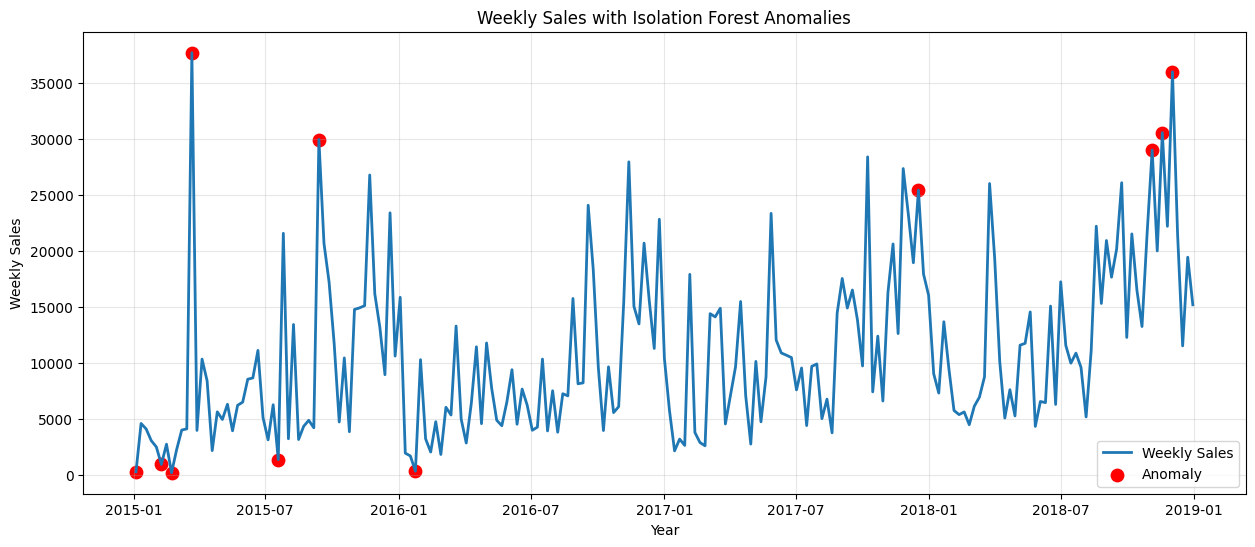

In [23]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

anomaly_points = weekly_sales[
    weekly_sales["Isolation_Result"] == "Anomaly"
]

plt.scatter(
    anomaly_points.index,
    anomaly_points["Sales"],
    color="red",
    s=80,
    marker="o",
    label="Anomaly"
)

plt.title("Weekly Sales with Isolation Forest Anomalies")

plt.xlabel("Year")
plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [24]:
anomaly_points

,Sales,Isolation_Result
Order Date,,
2015-01-04,304.508,Anomaly
2015-02-08,968.534,Anomaly
2015-02-22,224.912,Anomaly
2015-03-22,37703.665,Anomaly
2015-07-19,1387.686,Anomaly
2015-09-13,29959.137,Anomaly
2016-01-24,358.522,Anomaly
2017-12-17,25449.800,Anomaly
2018-11-04,29017.467,Anomaly


### Observation

- Isolation Forest successfully identified weeks with unusually high or unusually low sales.
- These anomalies may correspond to promotional campaigns, festive seasons, special discounts, inventory shortages, or unexpected market conditions.
- Highlighting these weeks enables businesses to investigate unusual sales behavior and improve future planning and forecasting.

In [25]:
weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
)

In [26]:
weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling_Mean"])
    / weekly_sales["Rolling_STD"]
)

In [27]:
weekly_sales["Z_Anomaly"] = np.where(

    abs(weekly_sales["Z_Score"]) > 2,

    "Anomaly",

    "Normal"

)

In [28]:
weekly_sales["Z_Anomaly"].value_counts()

Z_Anomaly
Normal    209
Name: count, dtype: int64

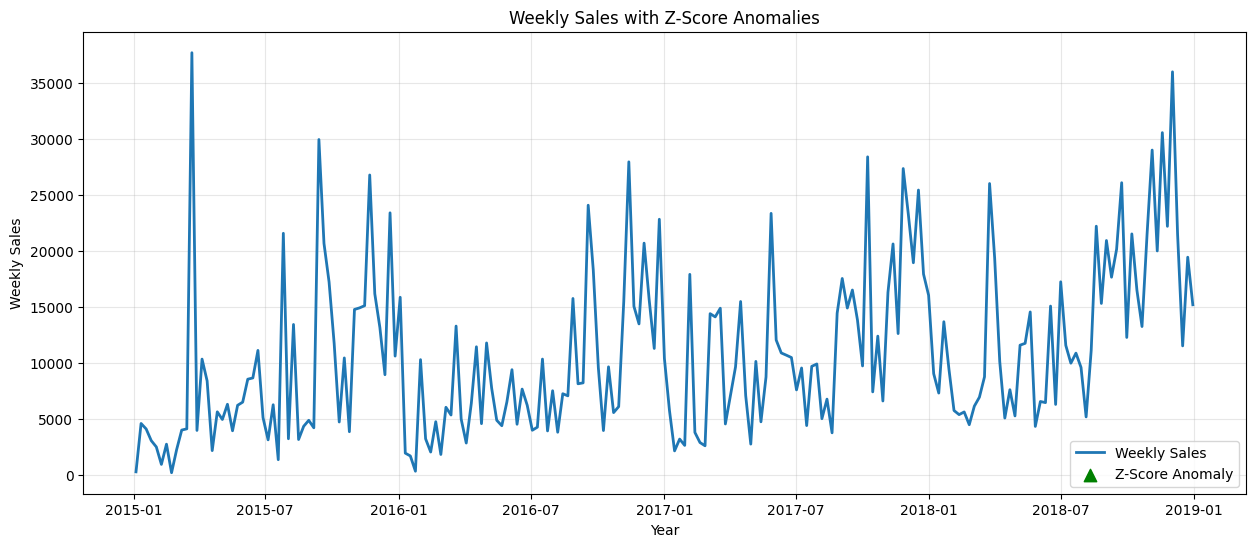

In [29]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    linewidth=2,
    label="Weekly Sales"
)

z_points = weekly_sales[
    weekly_sales["Z_Anomaly"]=="Anomaly"
]

plt.scatter(

    z_points.index,

    z_points["Sales"],

    color="green",

    s=80,

    marker="^",

    label="Z-Score Anomaly"

)

plt.title("Weekly Sales with Z-Score Anomalies")

plt.xlabel("Year")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [30]:
comparison = weekly_sales[
    [
        "Sales",
        "Isolation_Result",
        "Z_Anomaly"
    ]
]

comparison.head(15)

,Sales,Isolation_Result,Z_Anomaly
Order Date,,,
2015-01-04,304.508,Anomaly,Normal
2015-01-11,4619.108,Normal,Normal
2015-01-18,4130.533,Normal,Normal
2015-01-25,3092.544,Normal,Normal
2015-02-01,2527.914,Normal,Normal
2015-02-08,968.534,Anomaly,Normal
2015-02-15,2771.054,Normal,Normal
2015-02-22,224.912,Anomaly,Normal
2015-03-01,2289.643,Normal,Normal


In [31]:
same = comparison[
    (comparison["Isolation_Result"]=="Anomaly")
    &
    (comparison["Z_Anomaly"]=="Anomaly")
]

same

,Sales,Isolation_Result,Z_Anomaly
Order Date,,,


In [32]:
comparison[
    (comparison["Isolation_Result"]=="Anomaly")
    |
    (comparison["Z_Anomaly"]=="Anomaly")
]

,Sales,Isolation_Result,Z_Anomaly
Order Date,,,
2015-01-04,304.508,Anomaly,Normal
2015-02-08,968.534,Anomaly,Normal
2015-02-22,224.912,Anomaly,Normal
2015-03-22,37703.665,Anomaly,Normal
2015-07-19,1387.686,Anomaly,Normal
2015-09-13,29959.137,Anomaly,Normal
2016-01-24,358.522,Anomaly,Normal
2017-12-17,25449.800,Anomaly,Normal
2018-11-04,29017.467,Anomaly,Normal


### Comparison of Anomaly Detection Methods

- Isolation Forest identified **11 anomalous weeks** by learning the overall pattern of weekly sales.
- The Z-Score method identified weeks where sales deviated significantly from the recent rolling average.
- Several anomalies were detected by both methods, indicating strong evidence of unusual sales behavior.
- Some anomalies were detected by only one method because Isolation Forest considers the overall distribution of the data, whereas the Z-Score method relies solely on statistical deviation from the rolling mean.

## Possible Real-World Explanations for Detected Anomalies

- Weeks with exceptionally high sales may correspond to festive seasons, promotional campaigns, clearance sales, or holiday shopping periods.
- Weeks with unusually low sales may be caused by inventory shortages, supply chain disruptions, seasonal demand decline, or reduced customer activity.
- Sudden spikes or drops may also result from marketing campaigns, new product launches, or external economic events.
- Investigating these anomalies helps businesses improve forecasting accuracy and inventory planning.

# Task 5 Conclusion

Weekly sales anomalies were identified using two different approaches: Isolation Forest and Z-Score based detection.

Isolation Forest, a machine learning method, detected unusual sales weeks by learning the overall structure of the data, while the Z-Score method identified weeks with large statistical deviations from the rolling mean.

Comparing both methods showed that several anomalies were consistently identified, increasing confidence in those unusual sales events. The analysis demonstrates how anomaly detection can help businesses identify exceptional demand patterns, investigate unusual sales behavior, and improve forecasting and operational planning.

# Task 6 – Product Demand Segmentation using Clustering

## Objective

The objective of this task is to segment product sub-categories into different demand groups using K-Means Clustering. Product demand characteristics such as total sales volume, sales growth rate, sales volatility, and average order value are used as features for clustering.

The resulting clusters help businesses identify high-demand, stable-demand, growing, and declining product groups, enabling better inventory planning and demand management.

In [33]:
from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

In [34]:
total_sales = df.groupby("Sub-Category")["Sales"].sum()

In [35]:
average_order = df.groupby("Sub-Category")["Sales"].mean()

In [36]:
sales_volatility = df.groupby("Sub-Category")["Sales"].std()

In [37]:
yearly_sales = (
    df.groupby(
        [
            "Sub-Category",
            df["Order Date"].dt.year
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

In [38]:
growth_rate = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

In [39]:
growth_df = yearly_sales.copy()

growth_df["Growth"] = growth_rate

average_growth = (
    growth_df
    .groupby("Sub-Category")["Growth"]
    .mean()
)

In [40]:
cluster_data = pd.DataFrame({

    "Total Sales": total_sales,

    "Average Order Value": average_order,

    "Sales Volatility": sales_volatility,

    "Growth Rate": average_growth

})

cluster_data = cluster_data.fillna(0)

cluster_data.head()

,Total Sales,Average Order Value,Sales Volatility,Growth Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381
Appliances,104618.4030,227.926804,378.006735,0.399276
Art,26705.4100,34.019631,60.301752,0.166056
Binders,200028.7850,134.067550,568.099970,0.218736
Bookcases,113813.1987,503.598224,641.419280,0.238065


In [41]:
cluster_data.shape

(17, 4)

In [42]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [43]:
scaled_data[:5]

array([[ 0.31598599, -0.36354857, -0.36820849,  0.11450548],
       [-0.28817617, -0.34520236, -0.32287389,  0.16628324],
       [-1.07839653, -0.67617125, -0.68042053, -0.36114889],
       [ 0.67950874, -0.50540527, -0.1089421 , -0.24201087],
       [-0.19491939,  0.12532518, -0.02642822, -0.19829775]])

In [44]:
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

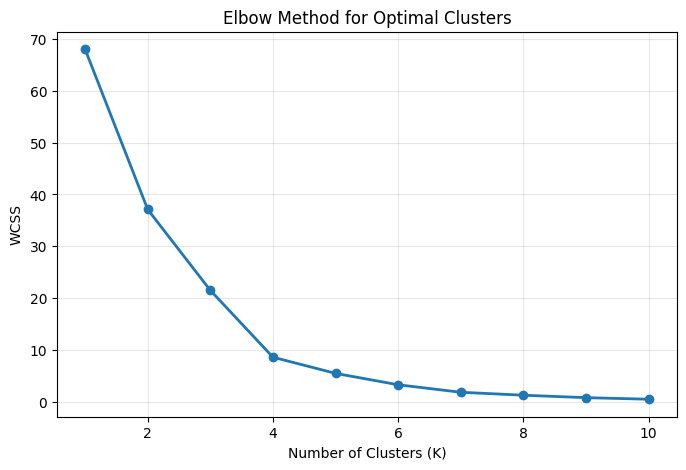

In [45]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method for Optimal Clusters")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.show()

### Observation

The Elbow Method was used to determine the appropriate number of clusters for K-Means. The point where the WCSS curve begins to flatten indicates the optimal number of clusters. This value is selected to achieve a balance between model simplicity and clustering accuracy.

In [46]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled_data)

cluster_data.head()

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381,2
Appliances,104618.4030,227.926804,378.006735,0.399276,1
Art,26705.4100,34.019631,60.301752,0.166056,1
Binders,200028.7850,134.067550,568.099970,0.218736,2
Bookcases,113813.1987,503.598224,641.419280,0.238065,1


In [47]:
cluster_data

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381,2
Appliances,104618.4030,227.926804,378.006735,0.399276,1
Art,26705.4100,34.019631,60.301752,0.166056,1
Binders,200028.7850,134.067550,568.099970,0.218736,2
Bookcases,113813.1987,503.598224,641.419280,0.238065,1
Chairs,322822.7310,531.833165,551.180296,0.071358,2
Copiers,146248.0940,2215.880212,3216.185499,0.846718,0
Envelopes,16128.0460,65.032444,85.170691,-0.027666,1
Fasteners,3001.9600,14.027850,12.466864,0.157034,1


In [48]:
cluster_data["Cluster"].value_counts()

Cluster
1    8
2    6
0    2
3    1
Name: count, dtype: int64

### Observation

Each product sub-category has been assigned to one of four clusters based on its sales characteristics. Products within the same cluster exhibit similar demand behavior, allowing them to be managed using similar inventory and stocking strategies.

In [49]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

cluster_data["PCA1"] = pca_data[:, 0]
cluster_data["PCA2"] = pca_data[:, 1]

cluster_data.head()

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381,2,-0.369152,-0.146390
Appliances,104618.4030,227.926804,378.006735,0.399276,1,-0.490906,0.296120
Art,26705.4100,34.019631,60.301752,0.166056,1,-1.282601,0.406386
Binders,200028.7850,134.067550,568.099970,0.218736,2,-0.258919,-0.624599
Bookcases,113813.1987,503.598224,641.419280,0.238065,1,-0.031793,-0.024216


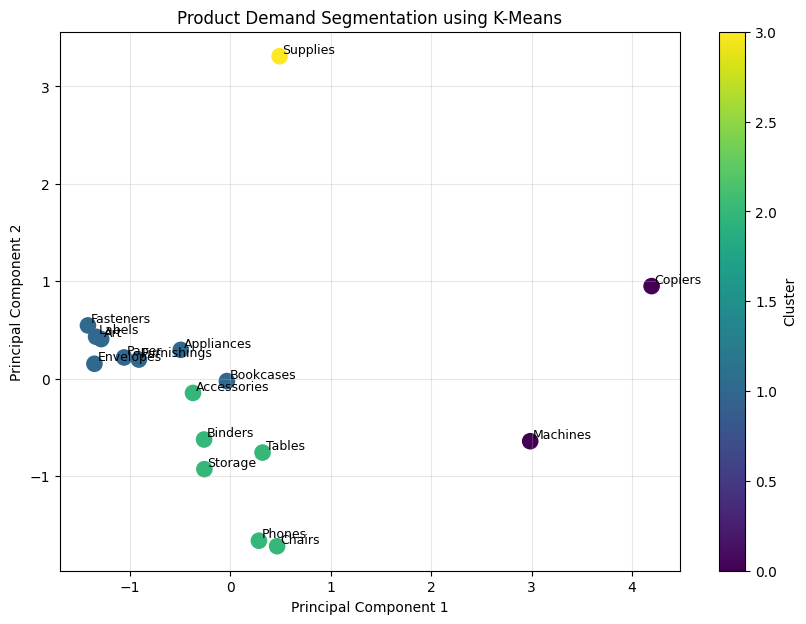

In [50]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    cluster_data["PCA1"],
    cluster_data["PCA2"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    s=120
)

for i in cluster_data.index:
    plt.text(
        cluster_data.loc[i, "PCA1"] + 0.03,
        cluster_data.loc[i, "PCA2"] + 0.03,
        i,
        fontsize=9
    )

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")

plt.grid(alpha=0.3)

plt.show()

In [51]:
cluster_data[
    [
        "Total Sales",
        "Average Order Value",
        "Sales Volatility",
        "Growth Rate",
        "Cluster"
    ]
].sort_values("Cluster")

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster
Sub-Category,,,,,
Copiers,146248.0940,2215.880212,3216.185499,0.846718,0
Machines,189238.6310,1645.553313,2765.102088,0.080060,0
Bookcases,113813.1987,503.598224,641.419280,0.238065,1
Appliances,104618.4030,227.926804,378.006735,0.399276,1
Envelopes,16128.0460,65.032444,85.170691,-0.027666,1
Furnishings,89212.0180,95.823865,148.421490,0.287889,1
Fasteners,3001.9600,14.027850,12.466864,0.157034,1
Art,26705.4100,34.019631,60.301752,0.166056,1
Paper,76828.3040,57.420257,78.492285,0.254131,1


In [52]:
cluster_summary = cluster_data.groupby("Cluster").mean()

cluster_summary

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,PCA1,PCA2
Cluster,,,,,,
0,167743.362500,1930.716763,2990.643794,0.463389,3.590020,0.154322
1,55331.883212,129.054568,184.885226,0.199589,-0.983248,0.277836
2,239495.780667,361.131228,484.147793,0.180965,0.032227,-0.973696
3,46420.308000,252.284283,938.087746,1.928448,0.492588,3.310846


In [53]:
cluster_labels = {

    0: "High Volume, Premium Products",

    1: "Low Volume, Stable Demand",

    2: "High Volume, Stable Demand",

    3: "Growing Demand"

}

cluster_data["Demand Segment"] = cluster_data["Cluster"].map(cluster_labels)

cluster_data

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,PCA1,PCA2,Demand Segment
Sub-Category,,,,,,,,
Accessories,164186.7000,217.178175,337.723800,0.376381,2,-0.369152,-0.146390,"High Volume, Stable Demand"
Appliances,104618.4030,227.926804,378.006735,0.399276,1,-0.490906,0.296120,"Low Volume, Stable Demand"
Art,26705.4100,34.019631,60.301752,0.166056,1,-1.282601,0.406386,"Low Volume, Stable Demand"
Binders,200028.7850,134.067550,568.099970,0.218736,2,-0.258919,-0.624599,"High Volume, Stable Demand"
Bookcases,113813.1987,503.598224,641.419280,0.238065,1,-0.031793,-0.024216,"Low Volume, Stable Demand"
Chairs,322822.7310,531.833165,551.180296,0.071358,2,0.467755,-1.720204,"High Volume, Stable Demand"
Copiers,146248.0940,2215.880212,3216.185499,0.846718,0,4.194037,0.950565,"High Volume, Premium Products"
Envelopes,16128.0460,65.032444,85.170691,-0.027666,1,-1.349906,0.153063,"Low Volume, Stable Demand"
Fasteners,3001.9600,14.027850,12.466864,0.157034,1,-1.414423,0.546838,"Low Volume, Stable Demand"


In [54]:
cluster_data[
    [
        "Total Sales",
        "Average Order Value",
        "Sales Volatility",
        "Growth Rate",
        "Demand Segment"
    ]
].sort_values("Demand Segment")

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Demand Segment
Sub-Category,,,,,
Supplies,46420.3080,252.284283,938.087746,1.928448,Growing Demand
Copiers,146248.0940,2215.880212,3216.185499,0.846718,"High Volume, Premium Products"
Machines,189238.6310,1645.553313,2765.102088,0.080060,"High Volume, Premium Products"
Accessories,164186.7000,217.178175,337.723800,0.376381,"High Volume, Stable Demand"
Binders,200028.7850,134.067550,568.099970,0.218736,"High Volume, Stable Demand"
Chairs,322822.7310,531.833165,551.180296,0.071358,"High Volume, Stable Demand"
Phones,327782.4480,374.180877,494.390228,0.123409,"High Volume, Stable Demand"
Storage,219343.3920,263.633885,354.907482,0.131799,"High Volume, Stable Demand"
Tables,202810.6280,645.893720,598.584981,0.164107,"High Volume, Stable Demand"



Based on the clustering results, the following inventory strategies are recommended:

### High Volume, Stable Demand
- Maintain high inventory levels.
- Ensure continuous stock availability.
- Prioritize these products during replenishment.

### High Volume, Premium Products
- Maintain sufficient stock while monitoring demand fluctuations.
- Use demand forecasting to avoid overstocking expensive products.
- Allocate higher inventory budgets due to higher order values.

### Growing Demand
- Gradually increase inventory levels.
- Monitor sales trends frequently.
- Plan additional procurement to meet increasing demand.

### Low Volume, Stable Demand
- Maintain limited inventory.
- Replenish based on actual demand.
- Avoid excessive stock to reduce holding costs.

### Observation

- K-Means clustering successfully segmented the product sub-categories into four distinct demand groups.
- The Elbow Method was used to determine an appropriate number of clusters before training the model.
- PCA reduced the feature space to two dimensions, making it easier to visualize the clusters.
- The identified demand segments provide valuable insights for inventory management, procurement planning, and product prioritization.
- Products with stable demand require consistent inventory, whereas growing and premium product groups should be monitored more closely due to changing demand patterns and higher business value.

# Task 6 Conclusion

Product sub-categories were successfully segmented using the K-Means clustering algorithm based on total sales, average order value, sales volatility, and sales growth rate.

The Elbow Method was applied to determine the optimal number of clusters, and PCA was used to visualize the clustering results. Four meaningful demand segments were identified: High Volume, Stable Demand; High Volume, Premium Products; Growing Demand; and Low Volume, Stable Demand.

These segments provide actionable business insights that can improve inventory planning, demand forecasting, procurement strategies, and overall supply chain efficiency by enabling different stocking policies for different product groups.